In [99]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy.random as rd

L'objectif est de déterminer la manière optimale de définir la fonction qui détermine le prix au mètre carré en fonction du taux d'occupation. On explorera également si le taux d'occupation initial influe sur les résultats de la simulation, quel bénéfice on peut attendre de l'exploitation d'un tel immeuble, et en combien de lots il est optimal de découper l'immeuble.

Plusieurs suppositions : 
- La surface totale du bâtiment $S$ est fixée.
- Chaque lot a la même surface $s$, il y a donc $\displaystyle \frac{S}{s}\equiv N$ lots.
- L'espérance du taux d'occupation initial est de $80\%$.
- La fonction de prix $g$ ne dépend que du taux d'occupation $\tau$.
- On prend $g$ strictement croissante, telle que $\displaystyle g : [0;1]\to[0,L_H]$ (L_H€/an étant un prix extrêmement élevé au mètre carrée, au-dessus duquel on considère que l'on n'ira pas).
- Chaque lot a la même probabilité $p_t$ que les autres d'être acheté le jour $t$. 
- La modélisation des probabilités d'arrivée et de départ est détaillée plus bas.
- On effectue la simulation sur $J$ jours.

Première remarque : il y a une relation linéaire entre le taux d'occupation et le bénéfice retiré de la gestion de l'immeuble. 
$$\displaystyle B_t=\tau_t\times S \times \frac{g(\tau_t)}{365}$$
Ce bénéfice est calculé par jour et le bénéfice final est donc le suivant : 
$$\displaystyle B_{final} = \sum_{t=1}^{J}B_t = \frac{S}{365}\sum_{t=1}^{J}\tau_t g(\tau_t)$$

Modélisation des probabilités de départ et d'arrivée : 

1) Notations : 

Ces probabilités doivent être faibles, comme il y a beaucoup de lots, si elles étaient hautes on assisterait à un va-et-vien extrêmement intense des entreprise dans les bureuax, ce qui ne correspond pas à la réalité (en moyenne, une entreprise retse $6$ ans dans les mêmes locaux). La probabilité de départ comme d'arrivée ne prend qu'un seul argument : le loyer au mètre carré. S'il est élevé, la probabilité de départ sera plus élevée et celle d'arrivée sera plus faible, et vice-versa. On a donc deux courbes, une strictement croissante en $L$ (la probabilité de départ) et une strictement décroissante en $L$ (la probabilité d'arrivée). Ces deux courbes se croisent donc en un unique point $(L_M,\overline{t})$, qui représente donc le loyer auquel on a un équilibre (même probabilité de départ que d'arrivée, notée $\overline{t}$). Cette dernière probabilité fixe aussi le taux moyen d'occupation attendu. On note ensuite $L_H$ le loyer maximal, au-dessus duquel l'agence immobilière n'ira pas. Ici, la probabilité de départ est maximale, elle vaut $\displaystyle \frac{1}{kN}$ avec $k\in\mathbb{R}_+$ un paramètre permettant de contrôler l'espérance du nombre de jours avant le premier départ dans cette configuration, de même que l'espérance du nombre de jours à attendre avant le premier emménagement dans le cas où le loyer est minimal et donc la probabilité d'arrivée maximale. On a donc que $\displaystyle \overline{t}\in\left]0;\frac{1}{kN}\right[$. On modélise les fonctions $\displaystyle p_d(L)$ et $p_a(L)$ avec une exponentielle afin de modéliser une croissance pouvant être relativement brusque quand on atteint le loyer à partir duquel les locaux ne sont plus considérés comme "bon marché", loyer que l'on note $L_M$.

2) Modélisation de la probabilité de départ : 
La forme générale de la fonction $p_d$ est donc : $\displaystyle p_d(L) = \frac{L}{a}e^{\frac{L}{b}}$ avec $a$ et $b$ à déterminer. On a trois contraintes sur la fonction $p_d$ : 
- $p_d(0)=0$, 
- $p_d(L_M)=\overline{t}$
- $\displaystyle p_d(L_H)=\frac{1}{kN}$

On peut à présent trouver les valeurs de $a$ et $b$. 

Des contraintes n°2 et 3, il vient directement que l'on peut noter $\displaystyle a=kNL_He^{\frac{L_H}{b}}$ et $a=\frac{L_M}{\overline{t}}e^{\frac{L_M}{b}}$.

$\displaystyle \iff kNL_He^{\frac{L_H}{b}} = \frac{L_M}{\overline{t}}e^{\frac{L_M}{b}}$

$\displaystyle \iff \frac{\overline{t}kNL_H}{L_M}e^{\frac{L_H}{b}}-e^{\frac{L_M}{b}}=0$

$\displaystyle \iff \frac{\overline{t}kNL_H}{L_M}e^{\frac{L_H}{b}}-\left(e^{\frac{L_H}{b}}\right)^{\frac{L_M}{L_H}}=0$ (on note $\displaystyle X \equiv e^{\frac{L_H}{b}}$)

$\displaystyle \iff X\left(\frac{\overline{t}kNL_H}{L_M} - X^{\frac{L_M}{L_H}-1}\right)=0$

Or, $X>0$, donc : 

$\displaystyle X^{\frac{L_M}{L_H}-1} = \frac{\overline{t}kNL_H}{L_M}$

$\displaystyle \iff X = \left(\frac{\overline{t}kNL_H}{L_M}\right)^{\frac{1}{\frac{L_M}{L_H}-1}} = \left(\frac{\overline{t}kNL_H}{L_M}\right)^{\frac{L_H}{L_M-L_H}}$

$\displaystyle \implies \frac{L_H}{b}=\frac{L_H}{L_M-L_H}ln\left(\frac{\overline{t}kNL_H}{L_M}\right)$

$\displaystyle \iff b = \frac{L_M-L_H}{ln\left(\frac{\overline{t}kNL_H}{L_M}\right)}$

On peut donc à présent trouver la valeur de $a$ : 

$\displaystyle a = kNL_He^{\frac{L_H}{b}}=kNL_He^{\frac{L_H}{\frac{L_M-L_H}{ln\left(\frac{\overline{t}kNL_H}{L_M}\right)}}} = kNL_He^{\frac{L_H}{L_M-L_H}ln\left(\frac{\overline{t}kNL_H}{L_M}\right)} = kNL_H\left(\frac{\overline{t}kNL_H}{L_M}\right)^{\frac{L_H}{L_M-L_H}}$

On injecte dans la formule de $\displaystyle p_d(L)$ : 

$\displaystyle p_d(L)=\frac{L}{kNL_H\left(\frac{\overline{t}kNL_H}{L_M}\right)^{\frac{L_H}{L_M-L_H}}}e^{\frac{ln\left(\frac{\overline{t}kNL_H}{L_M}\right)}{L_M-L_H}L} = \frac{L}{kNL_H\left(\frac{\overline{t}kNL_H}{L_M}\right)^{\frac{L_H}{L_M-L_H}}}\left(\frac{\overline{t}kNL_H}{L_M}\right)^{\frac{L}{L_M-L_H}}$

3) Modélisation de la probabilité d'arrivée : 

On reprend les mêmes notations. Cette fois, la fonction que l'on recherche est de la forme $\displaystyle p_a(L)=c\left(1-\frac{L}{L_H}\right)e^{-dL}$.

On a toujours trois conditions à remplir : $\displaystyle p_a(0)=\frac{1}{kN}$, $p_a(L_M)=\overline{t}$, et $p_a(L_H)=0$. 

Cette fonction est bien décroissante convexe comme ce qu'on attend d'une probabilité de s'installer en fonction du loyer, et on vérifie directement que le paramètre $c$ vaut $\displaystyle \frac{1}{kN}$ en appliquant en $0$. On calcule ensuite le paramètre $d$ en appliquant en $L_M$ : 

$\displaystyle \frac{1}{kN}\left(1-\frac{L_M}{L_H}\right)e^{-dL_M}=\overline{t} \iff d=\frac{-ln\left(\frac{kN\overline{t}}{1-\frac{L_M}{L_H}}\right)}{L_M}$

Donc, $\displaystyle p_a(L)=\frac{1-\frac{L}{L_H}}{kN}e^{\frac{ln\left(\frac{kN\overline{t}}{1-\frac{L_M}{L_H}}\right)}{L_M}L} = \frac{L_H-L}{kNL_H}\left(\frac{\overline{t}kNL_H}{L_H-L_M}\right)^{\frac{L}{L_M}}$

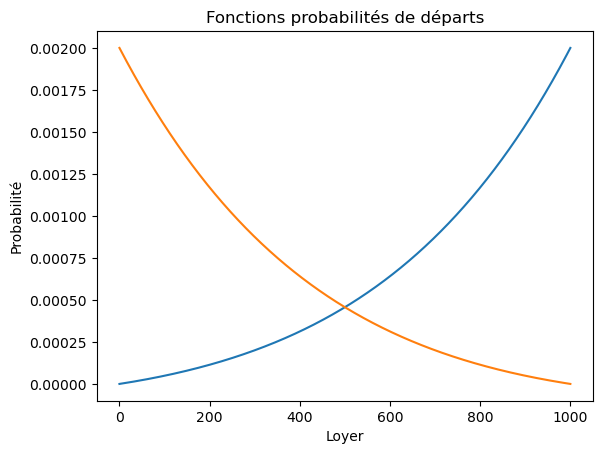

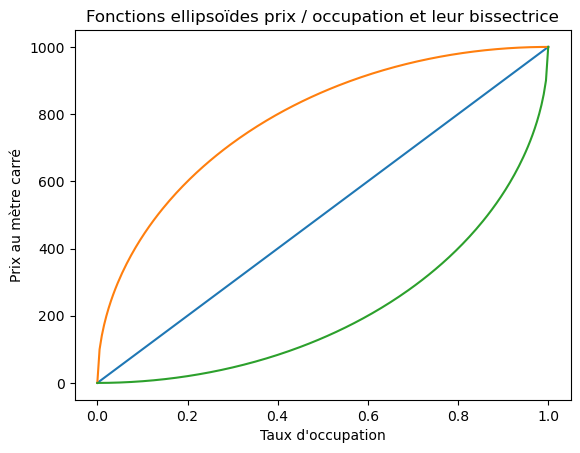

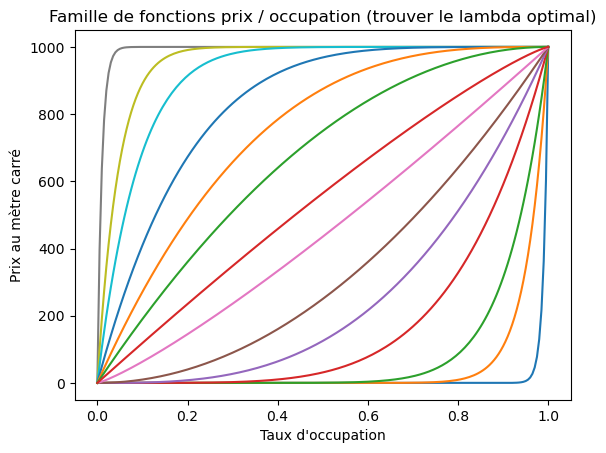

In [100]:
# On définit la surface totale
S = 10000

# On définit le nombre de lots
N = 100

# Surface de chaque lot
s = S/N

# On définit notre k
k = 5

# On définit notre loyer maximal L_H :
L_H = 1000

# On définit notre loyer habituel, à partir duquel ce n'est plus une si bonne affaire
L_M = 500

# On définit la probabilité d'équilibre t
t = 1/2190 # car en moyenne les entreprises restent 6 ans dans leurs locaux avant de changer

# On définit les fonctions de proba d'emménagement et de déménagement
ratio_usuel_departs = t*k*N*L_H/L_M

def p_d(L) : 
    return (L / ((k*N*L_H)*(ratio_usuel_departs**(L_H/(L_M-L_H))))) * ratio_usuel_departs**(L/(L_M-L_H))

def p_a(L) :
    return ((L_H-L)/(k*N*L_H)) * ((t*k*N*L_H)/(L_H-L_M))**(L/L_M)

ABSCISSES = np.linspace(0,1000,1001)
ORDONNEES_p_d = p_d(ABSCISSES)
ORDONNEES_p_a = p_a(ABSCISSES)
plt.plot(ABSCISSES,ORDONNEES_p_d)
plt.plot(ABSCISSES,ORDONNEES_p_a)
plt.title("Fonctions probabilités de départs")
plt.xlabel("Loyer")
plt.ylabel("Probabilité")
plt.show()

# On définit le nombre de jour de la simulation
J = 7300

# Espérance du taux d'occupation initial de E
E = 0.9

def g_identite(x) :
    return L_H*x

def g_ellipse_sup(x) :
    return L_H*np.sqrt(1-(x-1)**2)

def g_ellipse_inf(x) :
    return L_H - L_H*np.sqrt(1-x**2)

X = np.linspace(0,1,201)

plt.plot(X, g_identite(X))

plt.plot(X,g_ellipse_sup(X))

plt.plot(X,g_ellipse_inf(X))
plt.title("Fonctions ellipsoïdes prix / occupation et leur bissectrice")
plt.xlabel("Taux d'occupation")
plt.ylabel("Prix au mètre carré")
plt.show()

def g_inf(l, x) :
    return L_H*x**(1+1/l)

for l in [0.01, 0.05, 0.1, 0.25, 0.5, 1, 5] :
    plt.plot(X, g_inf(l, X))

def g_sup(l, x) :
    return L_H*(1-(1-x)**(1+1/l))

for l in [0.01, 0.05, 0.1, 0.25, 0.5, 1, 5] :
    plt.plot(X, g_sup(l, X))
plt.title("Famille de fonctions prix / occupation (trouver le lambda optimal)")
plt.xlabel("Taux d'occupation")
plt.ylabel("Prix au mètre carré")
plt.show()

Journée type : 
- L'agences immobilière observe un taux de vacance
- L'agence immobilière fixe le prix du loyer
- L'agence immobilière perçoit les loyers
- Les entreprises qui souhaitent partir partent
- Les entreprises qui souhaitent s'installer s'installent (selon le taux de vacance non actualisé car ils ne possèdent pas l'information que certaines entrepries souaitaient partir). Ils signent le bail ce jour et commenceront à payer le lendemain.
- Nouveau taux de vacance

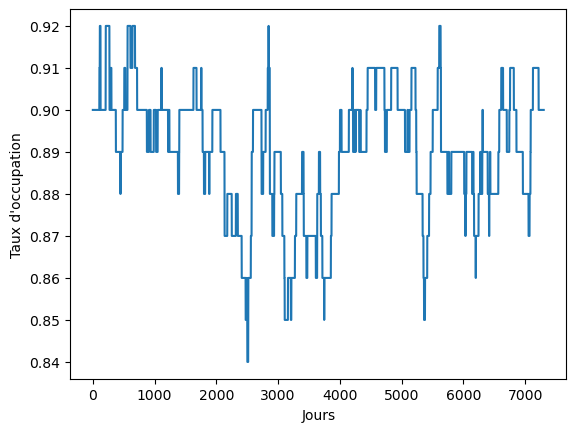

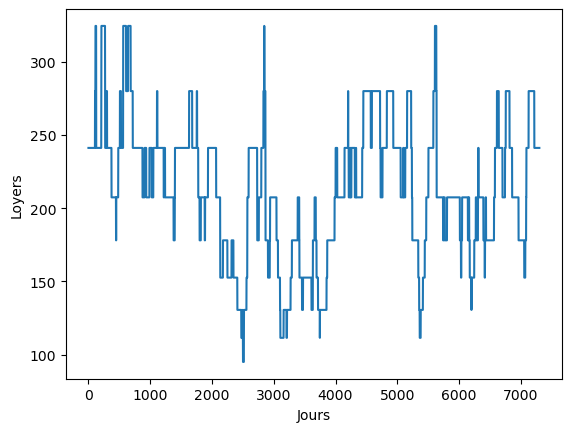

Bénéfice total en 20.0 années : 38176794.031658456
Nombre total d'arrivées : 94
Nombre total de départs : 94


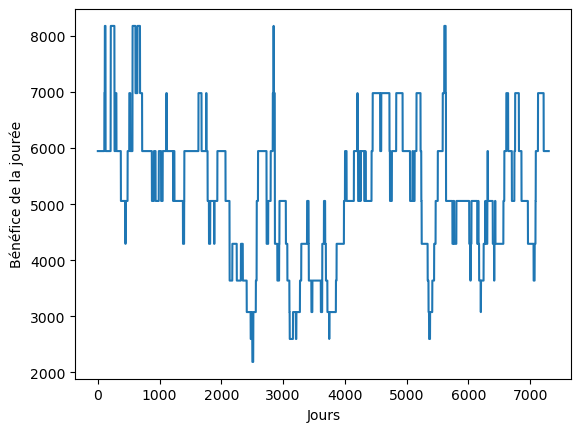

In [101]:
# Premier test avec un paramétrage bien précis du modèle. On cherchera à l'optimiser et à l'explorer plus en détail dans les prochaines cellules

def simulation(J, inf_ou_sup, l) :

    Loyers = []
    Benefice = []
    nb_installations = 0
    nb_departs = 0
    lots_occupes_ou_non = []
    for i in range(100) :
        if rd.random()<E :
            lots_occupes_ou_non.append(1)
        else : 
            lots_occupes_ou_non.append(0)
    taux_d_occupation_initial = sum(lots_occupes_ou_non)/100
    taux_d_occupation = []

    for j in range(J) : 
        if j == 0 : 
            taux_d_occupation_du_jour = taux_d_occupation_initial
            taux_d_occupation.append(taux_d_occupation_initial)
        if inf_ou_sup == "inf" : 
            loyer_du_jour = g_inf(l, taux_d_occupation_du_jour) # Le choix du paramétrage de la fonction correspond au choix d'un taux de vacance moyen 
        if inf_ou_sup == "sup" : 
            loyer_du_jour = g_sup(l, taux_d_occupation_du_jour)
        Loyers.append(loyer_du_jour)
        nombre_de_lots_occupes = sum(lots_occupes_ou_non)
        benefice_du_jour = loyer_du_jour*nombre_de_lots_occupes*s/365
        Benefice.append(benefice_du_jour)
        for i in range(len(lots_occupes_ou_non)) : 
            if lots_occupes_ou_non[i] == 1 :
                if rd.random()<p_d(loyer_du_jour) :
                    lots_occupes_ou_non[i] = 0
                    nb_departs += 1
            else : 
                if rd.random()<p_a(loyer_du_jour) : 
                    lots_occupes_ou_non[i] = 1
                    nb_installations += 1
        taux_d_occupation_du_jour = sum(lots_occupes_ou_non)/N
        taux_d_occupation.append(taux_d_occupation_du_jour)

    return [taux_d_occupation, Benefice, Loyers, nb_installations, nb_departs]

exemple_simu = simulation(J,"inf",0.08)

plt.plot(exemple_simu[0])
plt.xlabel("Jours")
plt.ylabel("Taux d'occupation")
plt.show()

plt.plot(exemple_simu[2])
plt.xlabel("Jours")
plt.ylabel("Loyers")
plt.show()

plt.plot(exemple_simu[1])
plt.xlabel("Jours")
plt.ylabel("Bénéfice de la jourée")
plt.xlabel

print(f"Bénéfice total en {J/365} années : {sum(exemple_simu[1])}")
print(f"Nombre total d'arrivées : {exemple_simu[3]}")
print(f"Nombre total de départs : {exemple_simu[4]}")

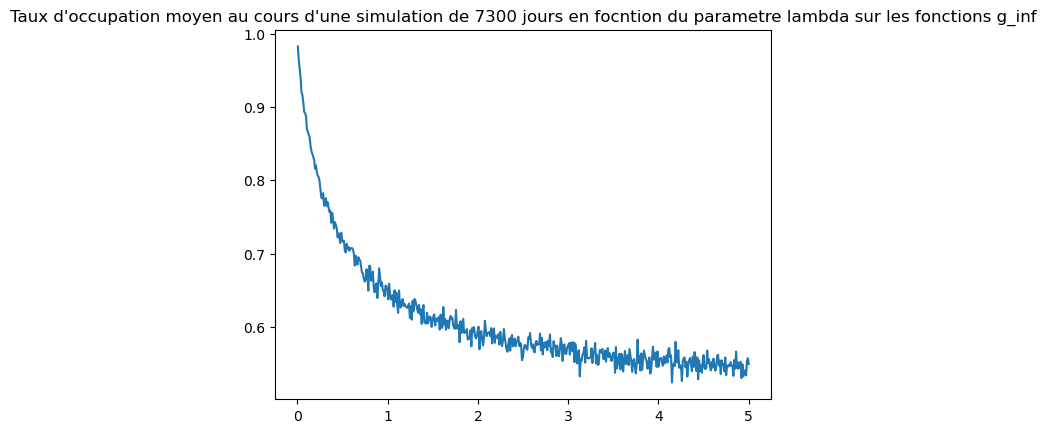

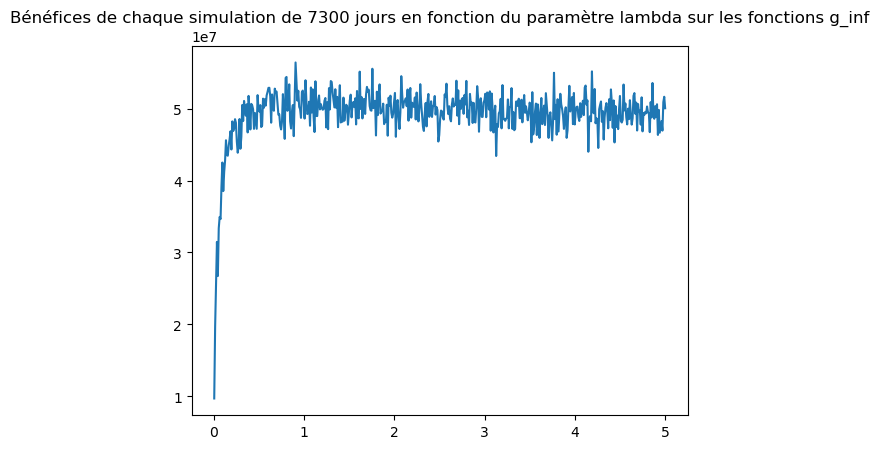

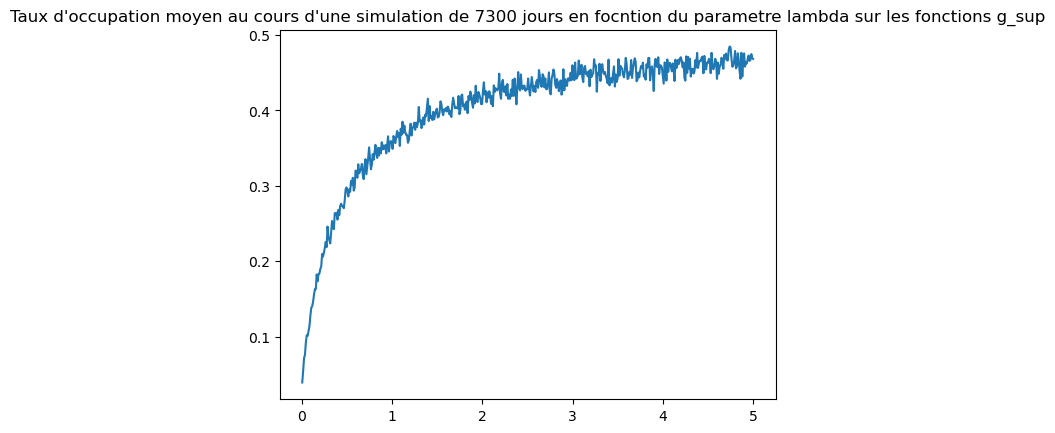

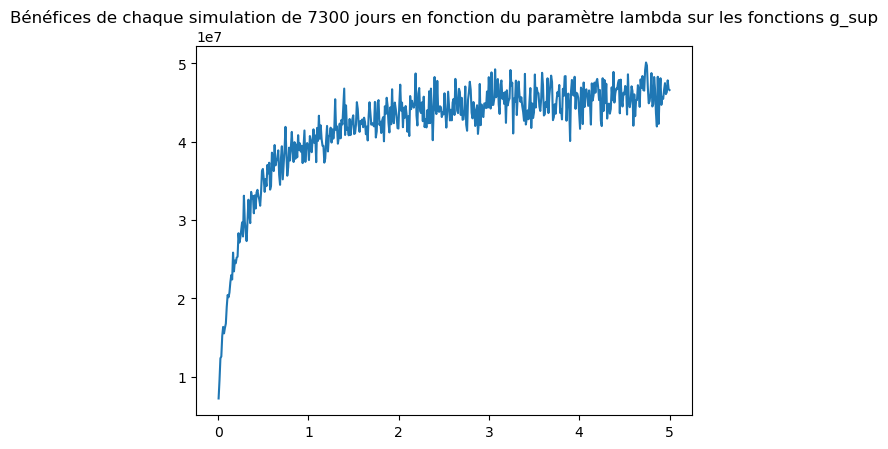

In [102]:
# Estimation de la correspondance taux de vacance moyen <--> paramètre l pour les fonctions g_inf

liste_de_parametres_l = np.linspace(0.005, 5, 500)

taux_d_occupation_moyens = []
benefices_moyens = []
loyers_moyens = []

for l in liste_de_parametres_l : 
    simu = simulation(J,"inf",l)
    taux_d_occupation_moyens.append(np.mean(simu[0][500:]))
    benefices_moyens.append(sum(simu[1][500:]))
    loyers_moyens.append(np.mean(simu[2][500:]))

plt.plot(liste_de_parametres_l, taux_d_occupation_moyens)
plt.title(f"Taux d'occupation moyen au cours d'une simulation de {J} jours en focntion du parametre lambda sur les fonctions g_inf")
plt.show()

plt.plot(liste_de_parametres_l, benefices_moyens)
plt.title(f"Bénéfices de chaque simulation de {J} jours en fonction du paramètre lambda sur les fonctions g_inf")
plt.show()

taux_d_occupation_moyens = []
benefices_moyens = []
loyers_moyens = []

for l in liste_de_parametres_l : 
    simu = simulation(J,"sup",l)
    taux_d_occupation_moyens.append(np.mean(simu[0][500:]))
    benefices_moyens.append(sum(simu[1][500:]))
    loyers_moyens.append(np.mean(simu[2][500:]))

plt.plot(liste_de_parametres_l, taux_d_occupation_moyens)
plt.title(f"Taux d'occupation moyen au cours d'une simulation de {J} jours en focntion du parametre lambda sur les fonctions g_sup")
plt.show()

plt.plot(liste_de_parametres_l, benefices_moyens)
plt.title(f"Bénéfices de chaque simulation de {J} jours en fonction du paramètre lambda sur les fonctions g_sup")
plt.show()


Comme on l'observe sur les graphiques, les fonctions $gsup$, qui convergent vers la fonction linéaire allant de l'origine du repère à $(1,L_H)$, sont sous-optimales. En effet, le bénéfice ne cesse d'augmenter avec lambda à mesure que l'on se rapproche de cette bissectrice, mais sans ne jamais dépasser les 50 000 000 d'euros de bénéfice. En revanche, les fonctions $ginf$ offrent une bien meilleure performance : on atteint le maximum de la tendance aux alentours de $\lambda = 1$, avant d'entamer une légère descente à mesure que $\lambda$ augmente et que l'on se rapproche de la bissectrice. 

Revenons enfin sur le rôle de $k$. Comme $k$ correspond au nombre de jours qu'il faudra attendre en moyenne, si l'immeuble se retrouve totalement vide, pour qu'une première entreprise élise domicile ici, $k$ peut être interprété comme une jauge de l'état de santé de l'économie. Avec un $k$ très élevé, on simule une crise majeure : les entreprises partent et plus aucune ne s'installe, le taux de vacance est très élevé et l'agence immobilière enregistre un bénéfice toujours plus faible. À l'inverse, un $k$ très faible correspond à une effervescence des entreprises : si l'immeuble se retrouve vide, il faut attendre très peu de temps avant que la première entreprise ne vienne s'installer. Le taux de vacance moyen est faible et l'agence immobilière, face à une forte demande, peut se permettre de pratiquer des prix élevés pour maximiser son bénéfice. L'état actuel de l'économie correspond à un $k$ environ égal à $5$, qui mène à un bénéfice maximal pour environ $90\%$ d'occupation du bâtiment.
